# Assignment 4: Comparative Training Methods
Roger Kutyna
[Github Repo](https://github.com/rkutyna/MSIT3103-GenAI-assignments/tree/main)

In [37]:
# Setup taken from assignment file


# If needed, uncomment to install.
%pip install torch numpy matplotlib tqdm nltk pandas datasets --quiet

import math
import os
import random
import time
import json
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import matplotlib.pyplot as plt
import pandas as pd

import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")


Note: you may need to restart the kernel to use updated packages.


#### Config

Taken from Assignment file

In [38]:

@dataclass
class Config:
    seed: int = 42
    # Apple silicon gpu acceleration
    device: str = "mps" if torch.mps.is_available() else "cpu"
    # data
    use_builtin_tiny_corpus: bool = True  # if False, tries tiny wikitext-2 via datasets
    context_len: int = 64
    train_frac: float = 0.9
    # model
    vocab_size: int = 0  # filled after building tokenizer
    d_model: int = 128
    n_heads: int = 4
    n_layers: int = 2
    dropout: float = 0.1
    # optimization
    batch_size: int = 64
    lr: float = 3e-3
    max_steps_pretrain: int = 1000
    max_steps_sft: int = 1000
    max_steps_rl: int = 200  # tiny on purpose
    eval_every: int = 50
    # generation
    temperature: float = 0.9
    top_k: Optional[int] = 50

CFG = Config()
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CFG.seed)

CFG.device


'mps'

#### Dataset creation

Taken from assignment file

In [39]:

BUILTIN_TINY_TEXT = "From fairest creatures we desire increase,\nThat thereby beauty's rose might never die,\nBut as the riper should by time decease,\nHis tender heir might bear his memory:\nBut thou contracted to thine own bright eyes,\nFeed'st thy light'st flame with self-substantial fuel,\nMaking a famine where abundance lies,\nThy self thy foe, to thy sweet self too cruel:"

def load_corpus(use_builtin: bool = True) -> str:
    """Return a small training corpus."""
    if use_builtin:
        return BUILTIN_TINY_TEXT.strip()
    else:
        try:
            from datasets import load_dataset
            ds = load_dataset("wikitext", "wikitext-2-raw-v1")
            # concatenate first N lines to keep it tiny
            lines = ds['train']['text'][:200]
            return "\n".join([l for l in lines if l is not None]).strip()
        except Exception as e:
            print("Falling back to builtin tiny text due to:", e)
            return BUILTIN_TINY_TEXT.strip()

# corpus_text = load_corpus(use_builtin = True)
corpus_text = load_corpus(use_builtin = False)

print(corpus_text[:300], "...")
print(len(corpus_text))


= Valkyria Chronicles III = 


 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStat ...
55358


#### Character Tokenizer

Taken from assignment file

In [40]:

class CharTokenizer:
    def __init__(self, text: str):
        vocab = sorted(set(text))
        self.stoi = {ch: i for i, ch in enumerate(vocab)}
        self.itos = {i: ch for ch, i in self.stoi.items()}
        self.vocab_size = len(vocab)

    def encode(self, s: str) -> List[int]:
        return [self.stoi[c] for c in s if c in self.stoi]

    def decode(self, ids: List[int]) -> str:
        return "".join(self.itos[i] for i in ids)

tokenizer = CharTokenizer(corpus_text)
CFG.vocab_size = tokenizer.vocab_size
print(f"CFG.vocab_size: {CFG.vocab_size}")

# Update the top_k based on vocab size
CFG.top_k = min(50, CFG.vocab_size) # ensure top_k is not greater than vocab_size
print(f"CFG.top_k: {CFG.top_k}")

#print(tokenizer.decode(range(tokenizer.vocab_size)))

CFG.vocab_size: 131
CFG.top_k: 50


#### Dataset and Dataloader

Taken from assignment file

In [41]:

class LMDataset(Dataset):
    def __init__(self, text: str, tokenizer: CharTokenizer, context_len: int = 64, split: str = "train", train_frac: float = 0.9):
        enc = tokenizer.encode(text)
        n = int(len(enc) * train_frac)
        if split == "train":
            self.data = enc[:n]
        else:
            self.data = enc[n:]
        self.context_len = context_len

    def __len__(self):
        return max(0, len(self.data) - self.context_len - 1)

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.context_len]
        y = self.data[idx+1:idx+self.context_len+1]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_ds = LMDataset(corpus_text, tokenizer, CFG.context_len, "train", CFG.train_frac)
val_ds = LMDataset(corpus_text, tokenizer, CFG.context_len, "val", CFG.train_frac)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, drop_last=True)

len(train_ds), len(val_ds)


(49757, 5471)

#### Tiny GPT-like model

Taken from assignment

In [42]:

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout, context_len):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        self.register_buffer("mask", torch.tril(torch.ones(context_len, context_len)).unsqueeze(0).unsqueeze(0))

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # (B, nh, T, hs)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v  # (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y

class Block(nn.Module):
    def __init__(self, d_model, n_heads, dropout, context_len):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout, context_len)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

class TinyGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, dropout, context_len):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Parameter(torch.zeros(1, context_len, d_model))
        self.blocks = nn.ModuleList([Block(d_model, n_heads, dropout, context_len) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

        # init
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb[:, :T, :]
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)  # (B, T, V)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=128, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -CFG.context_len:]
            logits, _ = self.forward(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-8)
            if top_k is not None:
                v, ix = torch.topk(logits, top_k)
                mask = logits < v[:, [-1]]
                logits[mask] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx


#### Evaluation and Plotting functions

Taken from assignment file

In [43]:

def eval_loss(model, loader):
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(CFG.device), y.to(CFG.device)
            _, loss = model(x, y)
            losses.append(loss.item())
    model.train()
    return float(np.mean(losses)) if losses else float('nan')

def perplexity(loss_val: float) -> float:
    try:
        return float(math.exp(loss_val))
    except OverflowError:
        return float('inf')

def sample_text(model, prompt: str, max_new_tokens=128):
    model.eval()
    inp = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=CFG.device)
    out = model.generate(inp, max_new_tokens=max_new_tokens, temperature=CFG.temperature, top_k=CFG.top_k)
    return tokenizer.decode(out[0].tolist())

def plot_losses(train_losses, val_losses, title="Training Curves"):
    plt.figure()
    xs = list(range(len(train_losses)))
    plt.plot(xs, train_losses, label="train")
    if val_losses:
        plt.plot(xs, val_losses, label="val")
    plt.title(title)
    plt.xlabel("Eval step (x{} steps)".format(CFG.eval_every))
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


#### Pre-Training

Taken from assignment file

In [55]:
# model training with ability to override model parameters

def train_model(d_model=CFG.d_model, n_layers=CFG.n_layers, n_heads = CFG.n_heads, context_len = CFG.context_len, dropout=CFG.dropout):
    model_pre = TinyGPT(CFG.vocab_size, d_model, n_layers, n_heads, dropout, CFG.context_len).to(CFG.device)
    opt = torch.optim.AdamW(model_pre.parameters(), lr=CFG.lr)

    train_losses_pre, val_losses_pre = [], []
    step = 0
    pbar = tqdm(total=CFG.max_steps_pretrain, desc="Pre-training")

    while step < CFG.max_steps_pretrain:
        for x, y in train_loader:
            x, y = x.to(CFG.device), y.to(CFG.device)
            _, loss = model_pre(x, y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            step += 1

            if step % CFG.eval_every == 0 or step == 1:
                vl = eval_loss(model_pre, val_loader)
                train_losses_pre.append(loss.item())
                val_losses_pre.append(vl)
                pbar.set_postfix(loss=loss.item(), val_loss=vl)

            if step >= CFG.max_steps_pretrain:
                break
    pbar.close()

    pt_train_last = train_losses_pre[-1] if train_losses_pre else float('nan')
    pt_val_last = val_losses_pre[-1] if val_losses_pre else float('nan')
    print("Pre-train done. Train loss ~", pt_train_last, " Val loss ~", pt_val_last, " PPL ~", perplexity(pt_val_last))
    plot_losses(train_losses_pre, val_losses_pre, title="Pre-training Curves")
    print(sample_text(model_pre, prompt="To be", max_new_tokens=120))
    return model_pre


#### Expermienting with d_model

d_model: 32


Pre-training:   0%|          | 0/1000 [00:11<?, ?it/s, loss=1.83, val_loss=2.06]

Pre-train done. Train loss ~ 1.8254480361938477  Val loss ~ 2.0603578216889327  PPL ~ 7.848777770831918


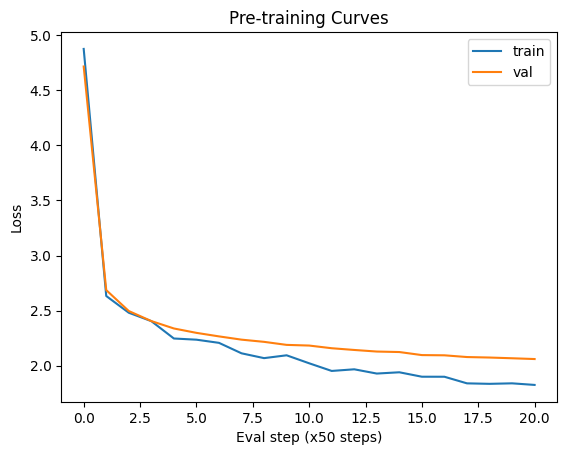

To bef 1862 , for ther Impros the evivelope as fals deaion swreres af gopmits Arkarls anempthis had imposat beg Linght durive
Time taken: 12.35 seconds
d_model: 64


Pre-training:   0%|          | 0/1000 [00:12<?, ?it/s, loss=1.55, val_loss=1.96]

Pre-train done. Train loss ~ 1.5459083318710327  Val loss ~ 1.9553619917701273  PPL ~ 7.066476567129544


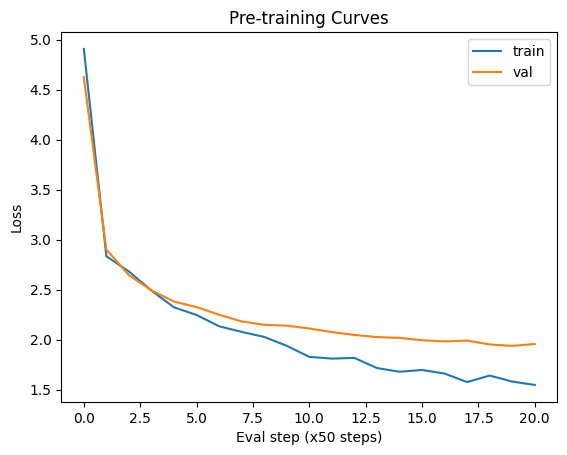

To being the theme renecept embers in epence and suced , al invitious . " 

 Flower Building . 

 Explayer inpeoted in the Ga
Time taken: 13.1 seconds
d_model: 96


Pre-training:   0%|          | 0/1000 [00:15<?, ?it/s, loss=1.41, val_loss=1.95]

Pre-train done. Train loss ~ 1.405179738998413  Val loss ~ 1.9454561696333044  PPL ~ 6.996822865277396


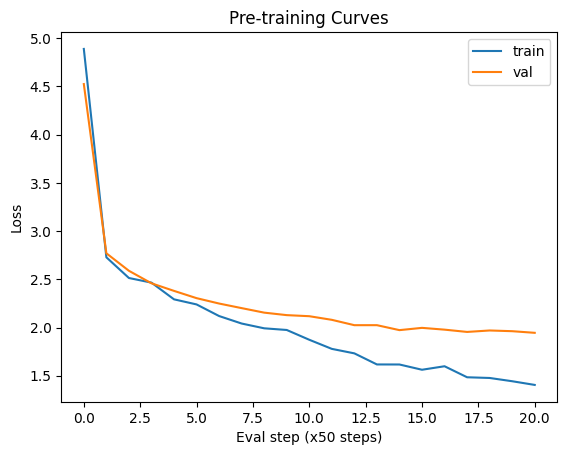

To began was , for making mest were kound the dad between an year 2010 . The with the men . During , in it the pacte previes 
Time taken: 15.92 seconds
d_model: 128


Pre-training:   0%|          | 0/1000 [00:18<?, ?it/s, loss=1.57, val_loss=2]   

Pre-train done. Train loss ~ 1.567077875137329  Val loss ~ 2.002111944030313  PPL ~ 7.40467786218677


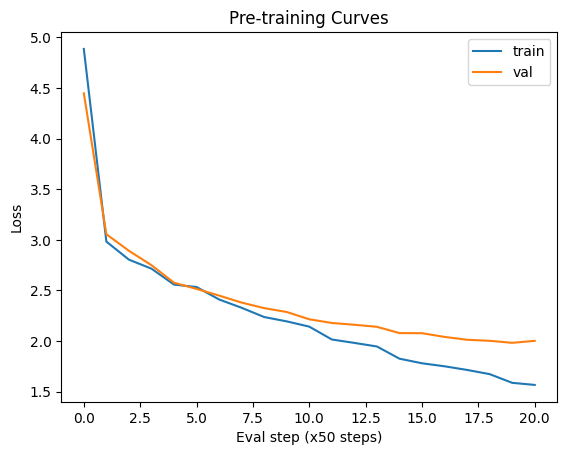

To began Calamilias State delocing the to History asorry recation with esent that to calomple arsenal for theme tran @-@ new 
Time taken: 19.35 seconds
d_model: 160


Pre-training:   0%|          | 0/1000 [00:23<?, ?it/s, loss=1.71, val_loss=2.01]

Pre-train done. Train loss ~ 1.707685112953186  Val loss ~ 2.0139338591519524  PPL ~ 7.4927348107118


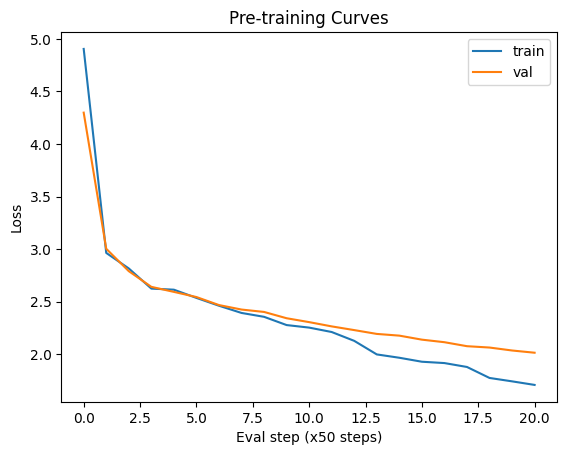

To be manchean of the sirving deents offiricial nited to the Little Rock dordgred muniltions . Its the game oposeting by afth
Time taken: 24.2 seconds
d_model: 192


Pre-training:   0%|          | 0/1000 [00:27<?, ?it/s, loss=1.59, val_loss=2.01]

Pre-train done. Train loss ~ 1.594541072845459  Val loss ~ 2.0066315047881185  PPL ~ 7.438219493302146


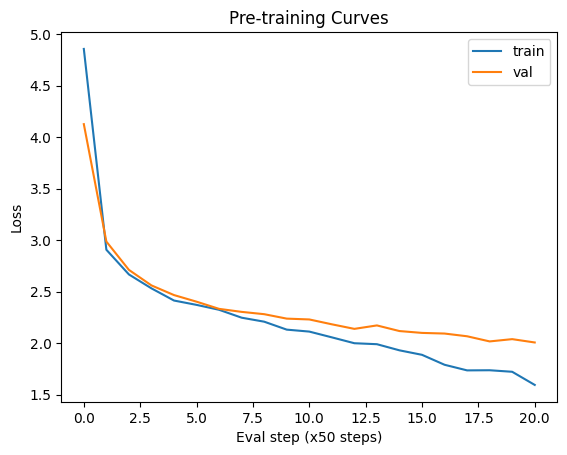

To beneral appt . Tole positive the Chistoded Tanteras tact ben to sentry relead and to uppbtach preding the 's lalll dumbed 
Time taken: 28.88 seconds
d_model: 224


Pre-training:   0%|          | 0/1000 [00:33<?, ?it/s, loss=1.54, val_loss=1.98]

Pre-train done. Train loss ~ 1.5433648824691772  Val loss ~ 1.977795532170464  PPL ~ 7.226794177028691


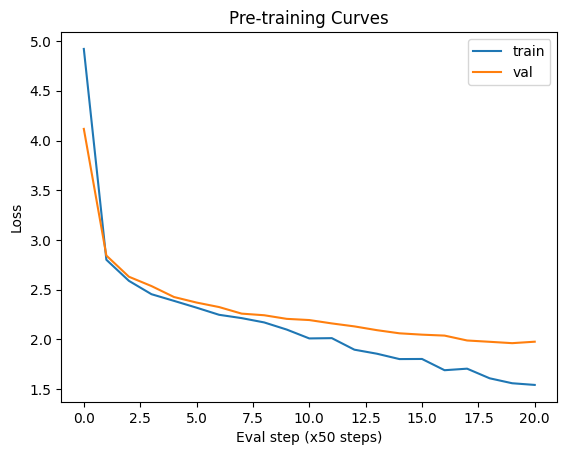

To being attteranued the Barker 's useries asped musics , tolder taska und allwing thereferrest the United Crowed , the Arkan
Time taken: 34.34 seconds
d_model: 256


Pre-training:   0%|          | 0/1000 [00:38<?, ?it/s, loss=1.48, val_loss=1.98]

Pre-train done. Train loss ~ 1.4825866222381592  Val loss ~ 1.9845161339815924  PPL ~ 7.275526153748097


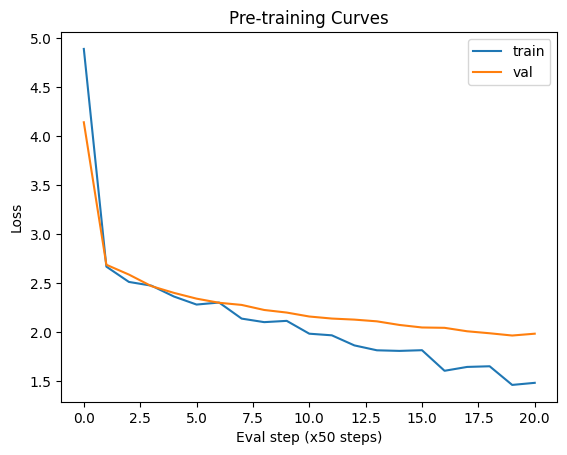

To between Novemen , February Born 3 , maleters sisted to diffiverpaided : Mayshi Barker 's . her wishout that would by the f
Time taken: 39.6 seconds


In [45]:
import time
pretrained_variable_d_model=[]
for i in range(32, 257, 32):
    print("d_model:",i)
    start_time=time.time()
    pretrained_variable_d_model.append((i, train_model(d_model = i)))
    print("Time taken:", round(time.time()-start_time, 2), "seconds")

It seems that a d_model value of 160 is best in this instance, although this will likely change with the number of attention heads and the number of layers.

#### Experimenting with n_heads

n_heads: 1


Pre-training:   0%|          | 0/1000 [00:19<?, ?it/s, loss=2.1, val_loss=2.2]  

Pre-train done. Train loss ~ 2.095466136932373  Val loss ~ 2.1963533457587747  PPL ~ 8.992162330511336


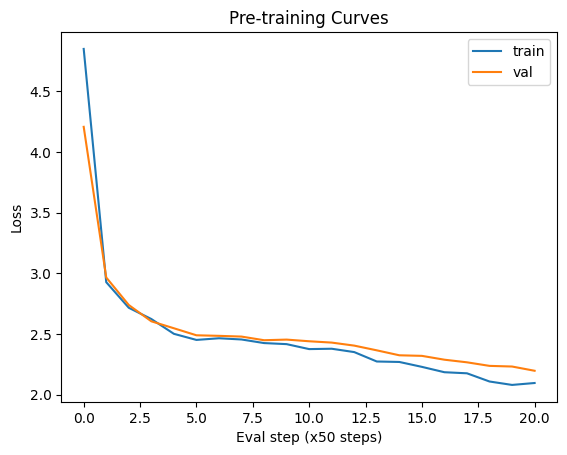

To be enened he and the nof mals for to thiled Nelelewere the Æshat for devi a remianing the the e Conpe One " , Gaccten Arti
Time taken: 20.02 seconds
n_heads: 2


Pre-training:   0%|          | 0/1000 [00:21<?, ?it/s, loss=1.45, val_loss=1.93]

Pre-train done. Train loss ~ 1.4529759883880615  Val loss ~ 1.9296904367559096  PPL ~ 6.887377832515478


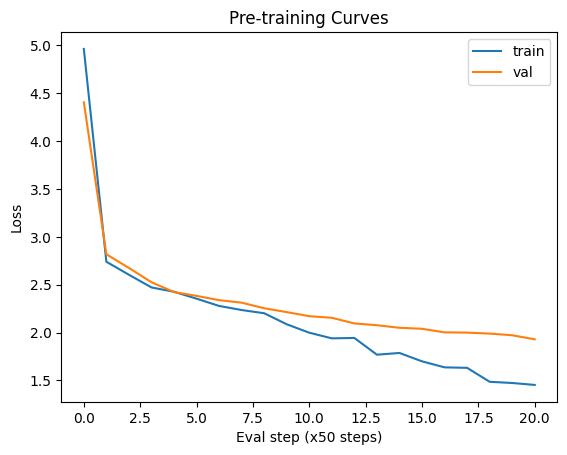

To being at 197 , the Camden , at as Captain Magazine 

 = = Fairiew became , and in the state early fancing a conting public
Time taken: 22.92 seconds
n_heads: 4


Pre-training:   0%|          | 0/1000 [00:23<?, ?it/s, loss=1.48, val_loss=1.99]

Pre-train done. Train loss ~ 1.4826550483703613  Val loss ~ 1.9941110723158892  PPL ~ 7.345670355047144


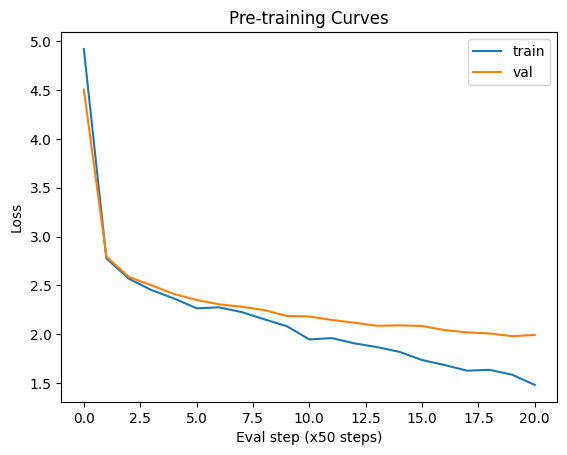

To be indenced . Lt. During and purped to munition as elopetion supolt and of mist ther aries ase hhe sent to mary removes av
Time taken: 23.79 seconds
n_heads: 5


Pre-training:   0%|          | 0/1000 [00:24<?, ?it/s, loss=1.38, val_loss=1.96]

Pre-train done. Train loss ~ 1.3781442642211914  Val loss ~ 1.9577205209171071  PPL ~ 7.083162727742696


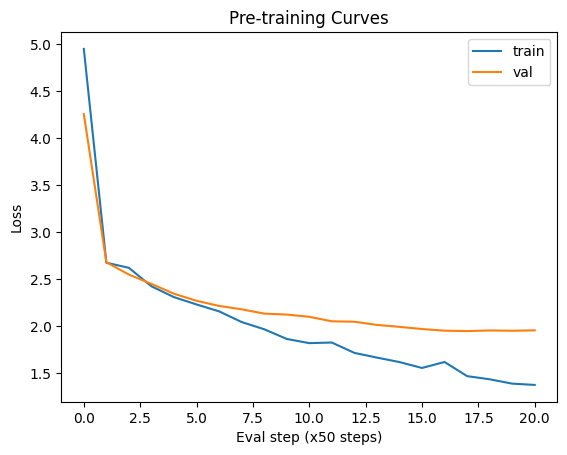

To began whinely atend the requening the sefor Harl 's Army in Calaman Army Navilansas were in the Arkansas super for Potenti
Time taken: 24.79 seconds
n_heads: 8


Pre-training:   0%|          | 0/1000 [00:27<?, ?it/s, loss=1.39, val_loss=1.98]

Pre-train done. Train loss ~ 1.3930845260620117  Val loss ~ 1.9777946682537304  PPL ~ 7.226787933682967


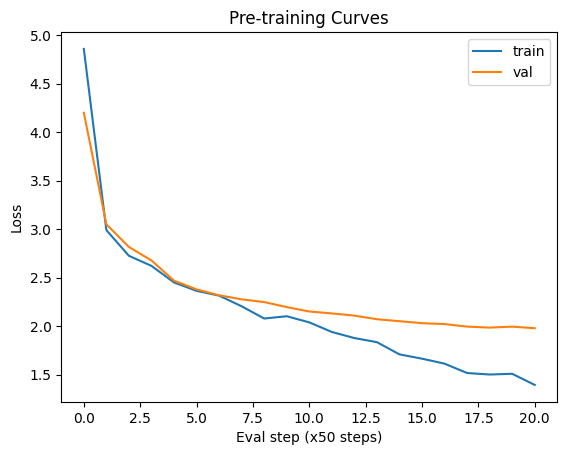

To be atle and these of searly and renitert conseques . Gest wourd childrband surroundls and that be liect to dendo orders th
Time taken: 28.17 seconds
n_heads: 10


Pre-training:   0%|          | 0/1000 [00:28<?, ?it/s, loss=1.21, val_loss=2.02]

Pre-train done. Train loss ~ 1.2096185684204102  Val loss ~ 2.021415706241832  PPL ~ 7.549004545136082


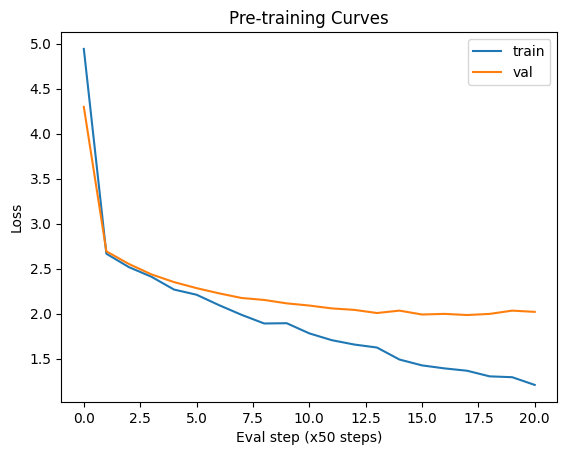

To be Little Rock under moried of the Summmarted of August 1863 . 


 In 1923 repark and festers in a 1923 , the Tower Buildi
Time taken: 29.58 seconds
n_heads: 16


Pre-training:   0%|          | 0/1000 [00:37<?, ?it/s, loss=1.3, val_loss=2.1]  

Pre-train done. Train loss ~ 1.2986631393432617  Val loss ~ 2.097548244981205  PPL ~ 8.146172988296861


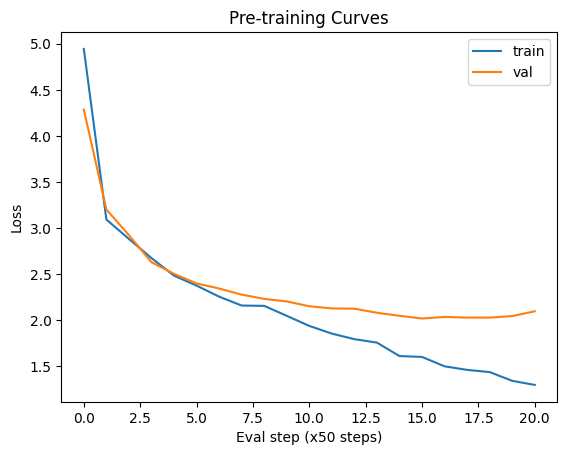

To began her spairiound lements of the gith is opints conf the governor as recorded work ankemed one remaded aninist . Park ,
Time taken: 38.07 seconds
n_heads: 20


Pre-training:   0%|          | 0/1000 [00:39<?, ?it/s, loss=1.18, val_loss=2.08]

Pre-train done. Train loss ~ 1.1838080883026123  Val loss ~ 2.081273920395795  PPL ~ 8.014672468381688


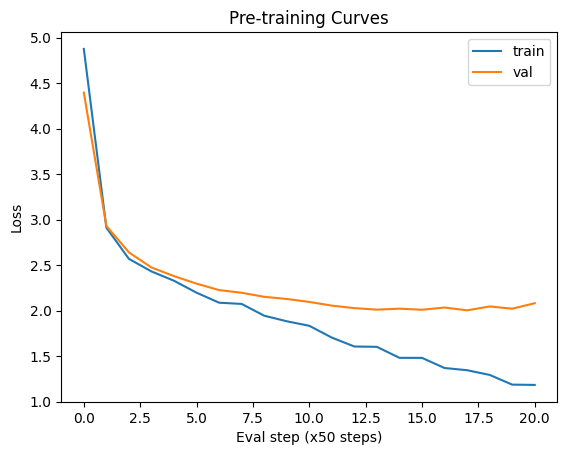

To be release of rely Art Sakimoto worked . The game was shigned used a thime 's games 't inl to the State , Gusurg Rebarnd ,
Time taken: 39.99 seconds
n_heads: 32


Pre-training:   0%|          | 0/1000 [00:49<?, ?it/s, loss=1.47, val_loss=2.02]

Pre-train done. Train loss ~ 1.4667952060699463  Val loss ~ 2.021121588875266  PPL ~ 7.546784578280477


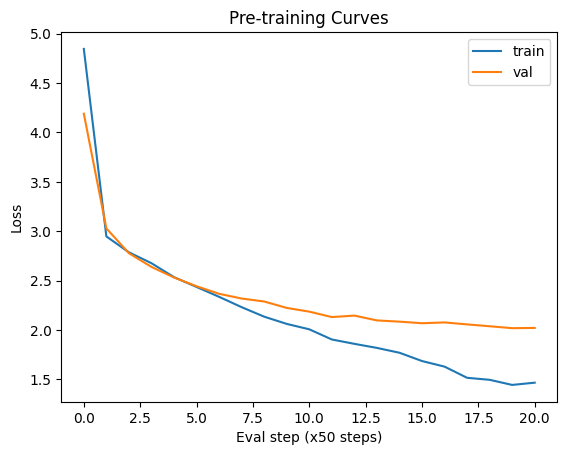

To be her for theme stach as well the pepplayer by the ordnance lanorgers , who twhich the ame munitions wallraned between we
Time taken: 50.44 seconds
n_heads: 40


Pre-training:   0%|          | 0/1000 [00:56<?, ?it/s, loss=1.13, val_loss=2.17]

Pre-train done. Train loss ~ 1.130470633506775  Val loss ~ 2.1688589138143204  PPL ~ 8.748295783626583


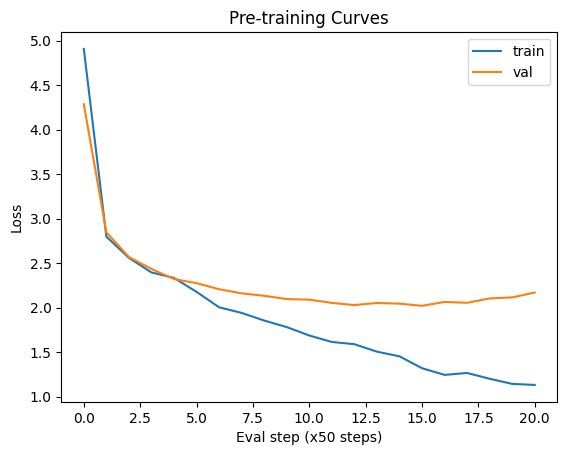

To between what stated by Major obef the Camden indergant , and the been be low calted manuffered scarces instructive at met 
Time taken: 57.38 seconds
n_heads: 80


Pre-training:   0%|          | 0/1000 [01:35<?, ?it/s, loss=1.13, val_loss=2.09]

Pre-train done. Train loss ~ 1.1324979066848755  Val loss ~ 2.090785799306982  PPL ~ 8.091270781831062


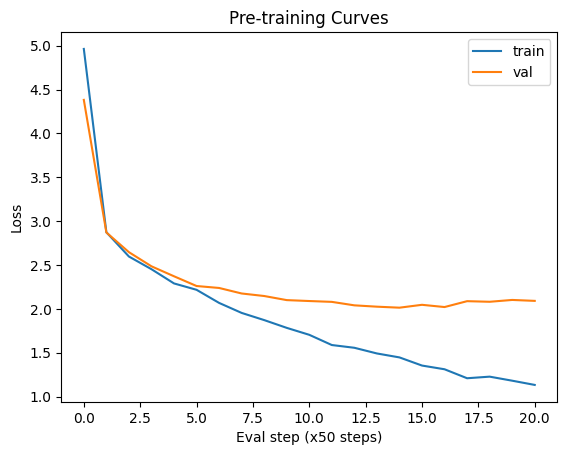

To be uning to douts to position of the Squick in in the new Litttle Rock under on through and pointion of the state opoper i
Time taken: 96.42 seconds
n_heads: 160


Pre-training:   0%|          | 0/1000 [02:42<?, ?it/s, loss=1.12, val_loss=2.21]

Pre-train done. Train loss ~ 1.1235551834106445  Val loss ~ 2.2144436106962315  PPL ~ 9.156313219353091


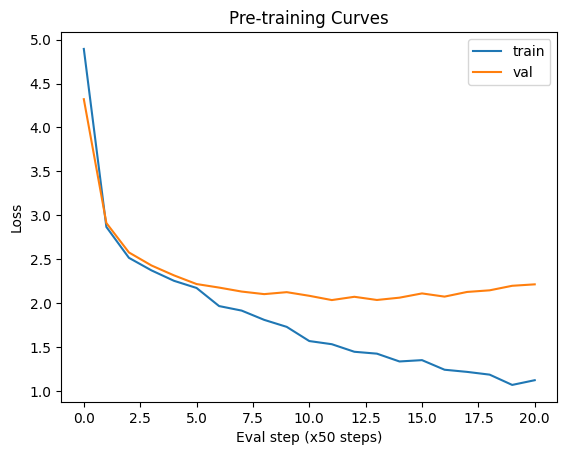

To be opening , which was dembened by She and , Gallian Army acter ean what sisten thos unth he station second most of the Va
Time taken: 162.81 seconds


In [46]:
import time
pretrained_variable_n_heads=[]
for i in [1, 2, 4, 5, 8, 10, 16, 20, 32, 40, 80, 160]:
    print("n_heads:",i)
    start_time=time.time()
    pretrained_variable_n_heads.append((i, train_model(n_heads = i, d_model=160)))
    print("Time taken:", round(time.time()-start_time, 2), "seconds")

It appears that increasing the number of attention heads within the range of 1-160 increases the performance of the model up to 16 heads, which yields the best performance. After this, the performance begins to decrease again. It seems that the model generalizes best at the lowest number of heads, but overfits as the number of heads increases. 

#### Experimenting with n_layers

n_layers: 1


Pre-training:   0%|          | 0/1000 [00:20<?, ?it/s, loss=1.27, val_loss=2.03]

Pre-train done. Train loss ~ 1.2726953029632568  Val loss ~ 2.0269339996225693  PPL ~ 7.590777318153286


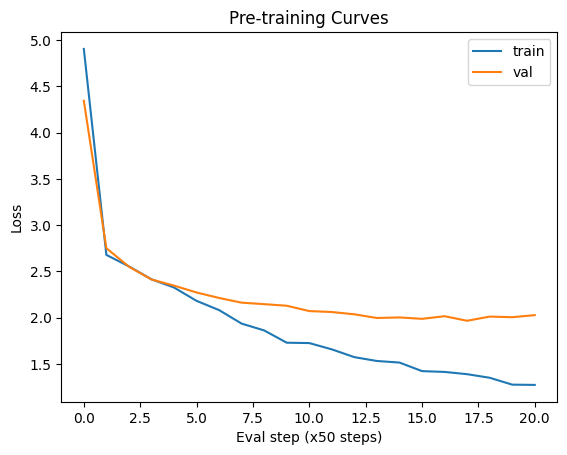

To be Work Done May Barker some , and the arsenal mappp an of the originaly its squencoies for they extory of they fir and le
Time taken: 21.4 seconds
n_layers: 2


Pre-training:   0%|          | 0/1000 [00:37<?, ?it/s, loss=1.21, val_loss=2.01]

Pre-train done. Train loss ~ 1.2074695825576782  Val loss ~ 2.0087877427830416  PPL ~ 7.454275368711683


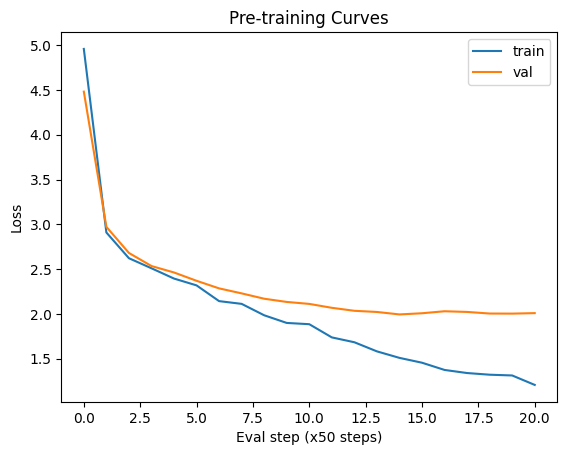

To began reoved a May 'gagainst affect strops federate in characters an in a causion was not the story of the Arsenal atttena
Time taken: 37.74 seconds
n_layers: 3


Pre-training:   0%|          | 0/1000 [00:53<?, ?it/s, loss=1.14, val_loss=2.05]

Pre-train done. Train loss ~ 1.1361064910888672  Val loss ~ 2.0504009513293995  PPL ~ 7.771016281056984


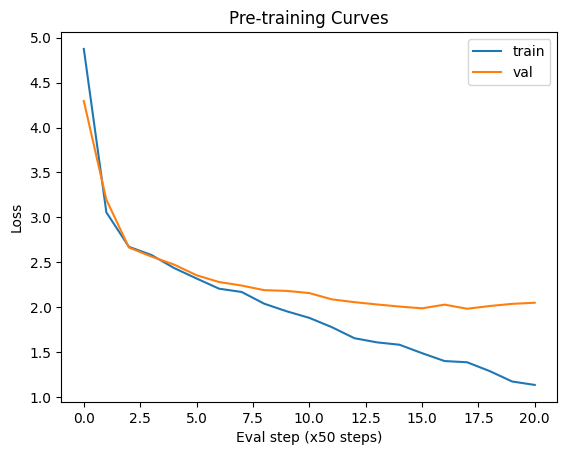

To before the were onded . " 

 = = Chroy = = = Early = = = Consters 


 Copoliking of the Towere Reist Seiki Arsenal Barrrly
Time taken: 54.51 seconds
n_layers: 4


Pre-training:   0%|          | 0/1000 [01:09<?, ?it/s, loss=1.33, val_loss=2.02]

Pre-train done. Train loss ~ 1.3299418687820435  Val loss ~ 2.0202695664237527  PPL ~ 7.540357286870161


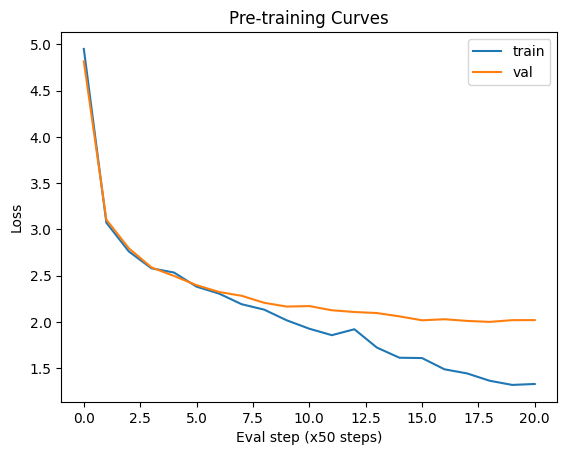

To be the late the latt the pirove of Little Rock Arsenal the " Arsenal " 's one solowing by their their Action Seiking the T
Time taken: 70.04 seconds
n_layers: 5


Pre-training:   0%|          | 0/1000 [01:26<?, ?it/s, loss=1.31, val_loss=2.03]

Pre-train done. Train loss ~ 1.3132426738739014  Val loss ~ 2.026142375609454  PPL ~ 7.58477065437335


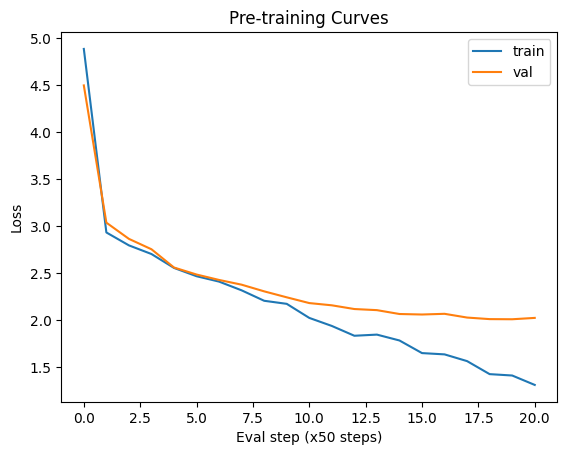

To beint as State their ame , halso a a the continued of " Arkarge R. Missimi , as he maninede from the Nitaral Histori " Eng
Time taken: 87.11 seconds


In [47]:
import time
pretrained_variable_n_layers=[]
for i in range(1,6):
    print("n_layers:",i)
    start_time=time.time()
    pretrained_variable_n_layers.append((i, train_model(n_layers = i, d_model=160, n_heads=16)))
    print("Time taken:", round(time.time()-start_time, 2), "seconds")

Similar to the the number of attention heads, increasing the number of layers also seems cause the model to overfit. This could likely be fixed by modifying the dropout to increase regularization. That being said, finding the perfect combination is out of the scope of this assignment and would likely take a large amount of time and compute to try various combinations with many more layers much greater depth. 

#### Changing dropout























Pre-training:   0%|          | 0/1000 [01:10<?, ?it/s, loss=1.81, val_loss=2.06]

Pre-train done. Train loss ~ 1.8096065521240234  Val loss ~ 2.0636881519766415  PPL ~ 7.87496036731117


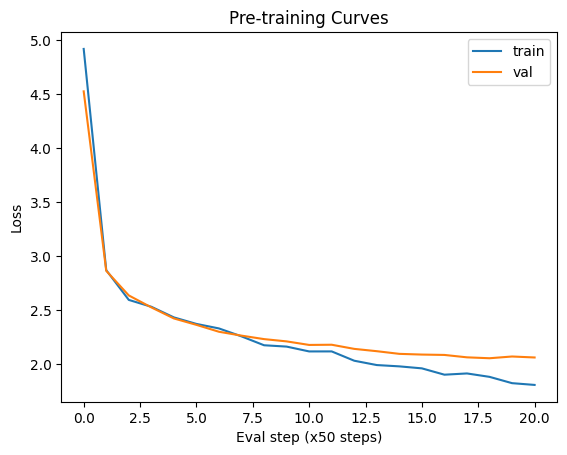

To beker of the Capail to ishem betime , in mand the smlissssime stas crelase on acting an to , whas supppppajased he @, a po


In [ ]:
pretrained_variable_n_layers.append((i, train_model(n_layers = 4, d_model=160, n_heads=16, dropout=0.3)))

It appears that increasing the dropout can significantly help with the overfitting issue. That being said, the gain in terms of loss and perplexity is relatively minimal. However, it seems like this model would benefit from longer training or a higher learning rate. 

In [73]:
sample_text(pretrained_variable_n_layers[-1][1], prompt="Write a Haiku", max_new_tokens=120)

"Write a Haiku Annd his , the prode adition the from Uniquated 's Artisimeus . The lower that spose stat servelopmes at were veing ame"

### Supervised Fine-tuning

In [ ]:
# Generated by GPT-5 (high reasoning) via Windsurf 9/26/25
# Prompt: Can you please extract the haiku's from assignment4/all_haiku.csv and put them 
# into a list in the form of this list @assignment4.ipynb#X44sZmlsZQ%3D%3D#L3-8 , 
# with the first element of each pair "Write a haiku:" and the second element as the haiku extracted from the file

# Haiku dataset sourced from Kaggle:
# https://www.kaggle.com/datasets/hjhalani30/haiku-dataset

import csv
from pathlib import Path

# Resolve CSV path whether you run the notebook from the repo root or from assignment_4/
CSV_PATH = Path("assignment_4/all_haiku.csv") if Path("assignment_4/all_haiku.csv").exists() else Path("all_haiku.csv")

def make_haiku_pairs(csv_path: Path, prompt: str = "Write a haiku:"):
    pairs = []
    with csv_path.open(newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        header = next(reader)
        header = [h.strip() for h in header]

        # Typical header looks like: ['', '0', '1', '2', 'source', 'hash']
        # Prefer named columns if present, else fall back to positions 1,2,3
        try:
            idx0 = header.index("0")
            idx1 = header.index("1")
            idx2 = header.index("2")
        except ValueError:
            idx0, idx1, idx2 = 1, 2, 3  # fallback if headers differ

        for row in reader:
            if not row:
                continue
            # Safeguard against short rows
            while len(row) <= max(idx0, idx1, idx2):
                row.append("")
            l1 = row[idx0].strip()
            l2 = row[idx1].strip()
            l3 = row[idx2].strip()
            if not (l1 or l2 or l3):
                continue
            haiku = "\n".join([s for s in (l1, l2, l3) if s])
            pairs.append((prompt, haiku))
    return pairs

# Build the list in the same structure as your SFT pairs
SFT_PAIRS_HAIKU = make_haiku_pairs(CSV_PATH)

# Optional: if you want to merge with an existing SFT_PAIRS list:
# SFT_PAIRS = SFT_PAIRS + SFT_PAIRS_HAIKU
# Or, if you only want the haiku pairs:
# SFT_PAIRS = SFT_PAIRS_HAIKU

# Quick sanity checks
print(f"Haiku pairs loaded: {len(SFT_PAIRS_HAIKU)}")
print("Example:", SFT_PAIRS_HAIKU[0])

Haiku pairs loaded: 144123
Example: ('Write a haiku:', 'fishing boats\ncolors of\nthe rainbow')


In [68]:
#  Taken from assignment file

SFT_PAIRS = [
    ("Write a short motto about learning:", " Learn, iterate, and grow."),
    ("Summarize: 'Neural nets learn patterns'.", " They learn patterns by adjusting weights."),
    ("Give a creative tagline for coffee:", " Sip ideas. Brew brilliance."),
    ("Explain: What is perplexity (1 sentence)?", " A measure of how well a language model predicts a sample."),
]
def sft_train(batch_size=CFG.batch_size, num_haikus= 100):
    def build_sft_text(pairs: List[Tuple[str, str]]) -> str:
        # Concatenate as instruction blocks to make conditional LM easy
        blocks = []
        for inp, out in pairs:
            blocks.append(f"Instruction: {inp}\nAnswer: {out}\n\n")
        return "".join(blocks)

    sft_text = build_sft_text(SFT_PAIRS_HAIKU[:num_haikus])
    #print(sft_text[:300])

    # Build tiny SFT dataset as LM on the concatenated text
    sft_train_ds = LMDataset(sft_text, tokenizer, CFG.context_len, "train", 0.9)
    sft_val_ds = LMDataset(sft_text, tokenizer, CFG.context_len, "val", 0.9)
    #print(len(sft_val_ds))
    sft_train_loader = DataLoader(sft_train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    sft_val_loader = DataLoader(sft_val_ds, batch_size=batch_size, shuffle=False, drop_last=True)

    # Copy the pre-trained model weights
    model_sft = TinyGPT(CFG.vocab_size, CFG.d_model, CFG.n_layers, CFG.n_heads, CFG.dropout, CFG.context_len).to(CFG.device)
    model_sft.load_state_dict(model_pre.state_dict())
    opt_sft = torch.optim.AdamW(model_sft.parameters(), lr=CFG.lr)

    train_losses_sft, val_losses_sft = [], []
    step = 0
    pbar = tqdm(total=CFG.max_steps_sft, desc="SFT")

    while step < CFG.max_steps_sft:
        for x, y in sft_train_loader:
            x, y = x.to(CFG.device), y.to(CFG.device)
            _, loss = model_sft(x, y)
            opt_sft.zero_grad(set_to_none=True)
            loss.backward()
            opt_sft.step()
            step += 1

            if step % CFG.eval_every == 0 or step == 1:
                vl = eval_loss(model_sft, sft_val_loader)
                train_losses_sft.append(loss.item())
                val_losses_sft.append(vl)
                pbar.set_postfix(loss=loss.item(), val_loss=vl)

            if step >= CFG.max_steps_sft:
                break
    pbar.close()

    sft_train_last = train_losses_sft[-1] if train_losses_sft else float('nan')
    sft_val_last = val_losses_sft[-1] if val_losses_sft else float('nan')
    print("SFT done. Train loss ~", sft_train_last, " Val loss ~", sft_val_last, " PPL ~", perplexity(sft_val_last))
    plot_losses(train_losses_sft, val_losses_sft, title="SFT Curves")

    print("Sample before SFT (pretrained):")
    print(sample_text(model_pre, prompt="Write a haiku:\nAnswer:", max_new_tokens=120))

    print("\nSample after SFT:")
    print(sample_text(model_sft, prompt="Write a haiku:\nAnswer:", max_new_tokens=120))
#print(val_losses_sft) 
#sft_train()

#### Experimenting with batch size



batch size: 32























SFT:   0%|          | 0/1000 [00:20<?, ?it/s, loss=1.14, val_loss=1.17]

SFT done. Train loss ~ 1.1414318084716797  Val loss ~ 1.1657162195160276  PPL ~ 3.2082198502067523


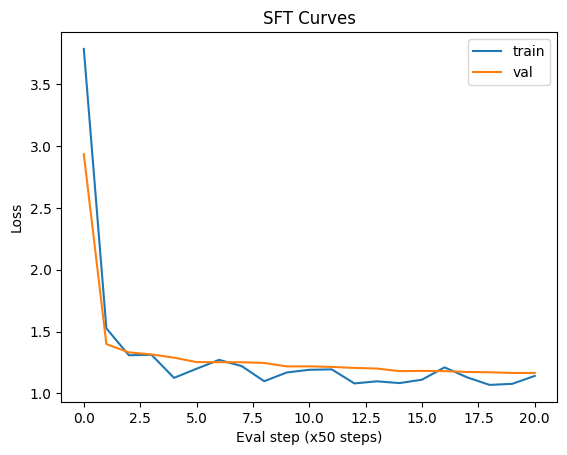

Sample before SFT (pretrained):
Write a haiku:
Answer: uble in to and Little Rock was " then prection kequaters wiles ad sended the plantely and the the for seal Baubttlen = 

Sample after SFT:
Write a haiku:
Answer: fall countain a chill
in the stars clive

Instruction: Write a haiku:
Answer: my of silence
the winte breathes scant wi
Time taken: 21.93 seconds


batch size: 48
























SFT:   0%|          | 0/1000 [00:21<?, ?it/s, loss=0.977, val_loss=1.14]

SFT done. Train loss ~ 0.9771447777748108  Val loss ~ 1.1434095400375324  PPL ~ 3.1374474020719774


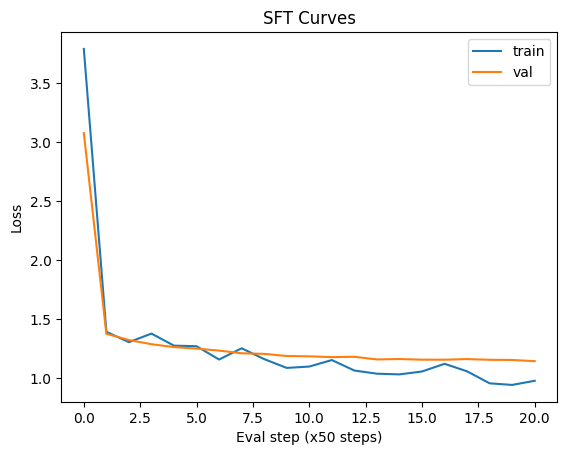

Sample before SFT (pretrained):
Write a haiku:
Answer: , owed that reare to beegare use in their and coartersion ( = いァァ光花 = Littla = = = = = = = = = = = = = = = = = 


 Tヴル


Sample after SFT:
Write a haiku:
Answer: desummer ad strink
the dawn sest rain
of hot me-
Instruction: Write a haiku:
Answer: overalling cout night
the sand of 
Time taken: 23.16 seconds


batch size: 64
























SFT:   0%|          | 0/1000 [00:22<?, ?it/s, loss=0.92, val_loss=1.14]

SFT done. Train loss ~ 0.9198870062828064  Val loss ~ 1.1412275472984594  PPL ~ 3.130608978030433


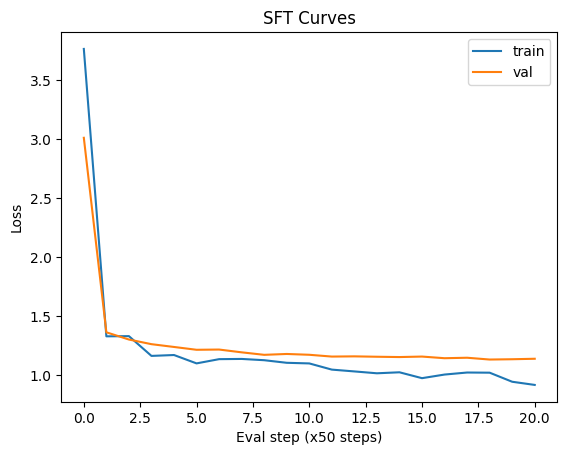

Sample before SFT (pretrained):
Write a haiku:
Answer: commpay as in 197 . Game 1 and , caiton of the were " The Baals @-@ M165747 the umission in offeries 


 May Dorother =

Sample after SFT:
Write a haiku:
Answer: leaving shemer
at her the stakes
of her day hand

Instruction: Write a haiku:
Answer: freeze sneple
chery saxocy news e
Time taken: 24.37 seconds


batch size: 80
























SFT:   0%|          | 0/1000 [00:25<?, ?it/s, loss=0.904, val_loss=1.16]

SFT done. Train loss ~ 0.9043752551078796  Val loss ~ 1.1594112570132684  PPL ~ 3.188055778007883


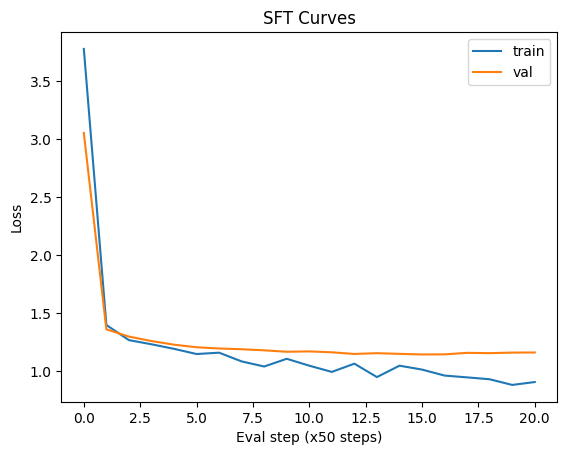

Sample before SFT (pretrained):
Write a haiku:
Answer: in a a pensios , than sup : bore a sto per . Arkans the Namend land the beat the min of the evexteration the cantion th

Sample after SFT:
Write a haiku:
Answer: old clouds -
winter to the moon
morning
at a on the river—

Instruction: Write a haiku:
Answer: a treee
everys of diref
Time taken: 27.22 seconds


batch size: 96
























SFT:   0%|          | 0/1000 [00:27<?, ?it/s, loss=0.878, val_loss=1.15]

SFT done. Train loss ~ 0.8775806427001953  Val loss ~ 1.1491207028483297  PPL ~ 3.155417140201798


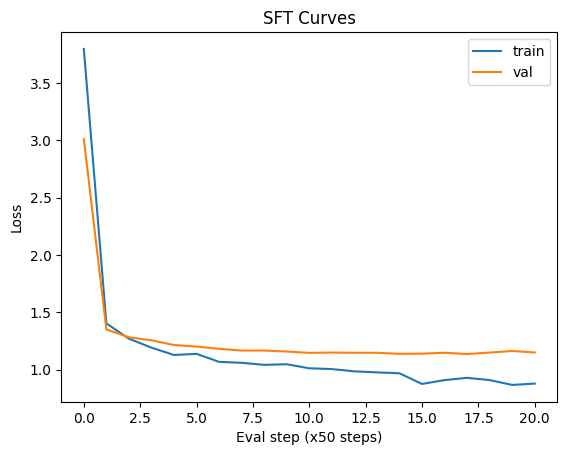

Sample before SFT (pretrained):
Write a haiku:
Answer: Du . The Lelember Dunilowed to peverntrion Little R. 


 Mers ' 1 pal , yinter Facesatios linsion the wer cons unde , o

Sample after SFT:
Write a haiku:
Answer: french -
i another Harvest
the tracks
Instruction: Write a haiku:
Answer: windows
of a lobow coffeee
watch the blow of 
Time taken: 28.83 seconds


batch size: 112
























SFT:   0%|          | 0/1000 [00:29<?, ?it/s, loss=0.818, val_loss=1.17]

SFT done. Train loss ~ 0.817693293094635  Val loss ~ 1.170155154588895  PPL ~ 3.2224925842551877


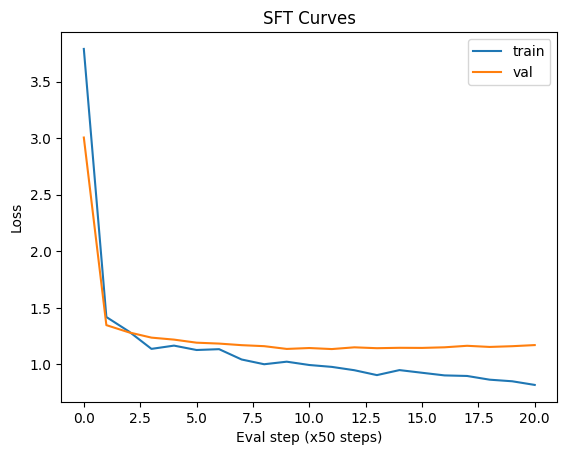

Sample before SFT (pretrained):
Write a haiku:
Answer: Fatach ose of charactivitent ofter pacted wer the dilon of the the Umiseve may fom , the ade creased moore , the the da

Sample after SFT:
Write a haiku:
Answer: too morning your
winter leeft wire
eaches from outh fog

Instruction: Write a haiku:
Answer: the blind gather Day
she r
Time taken: 31.47 seconds


batch size: 128
























SFT:   0%|          | 0/1000 [00:32<?, ?it/s, loss=0.807, val_loss=1.18]

SFT done. Train loss ~ 0.8071616888046265  Val loss ~ 1.1837797629482605  PPL ~ 3.2666982422227604


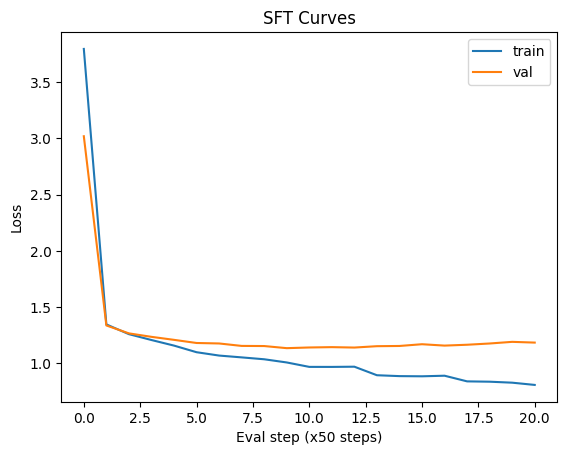

Sample before SFT (pretrained):
Write a haiku:
Answer: her to ventrurnans in of 197 , the was unikes gune turntroughe bet and mostent the citicted cons sped ching oriced of t

Sample after SFT:
Write a haiku:
Answer: my wife's day -
shadow'rd
of a cracks toffic
her silent grom

Instruction: Write a haiku:
Answer: summer rain
on my fac
Time taken: 34.47 seconds


batch size: 144
























SFT:   0%|          | 0/1000 [00:34<?, ?it/s, loss=0.805, val_loss=1.19]

SFT done. Train loss ~ 0.8045161962509155  Val loss ~ 1.1934878130753834  PPL ~ 3.29856594887134


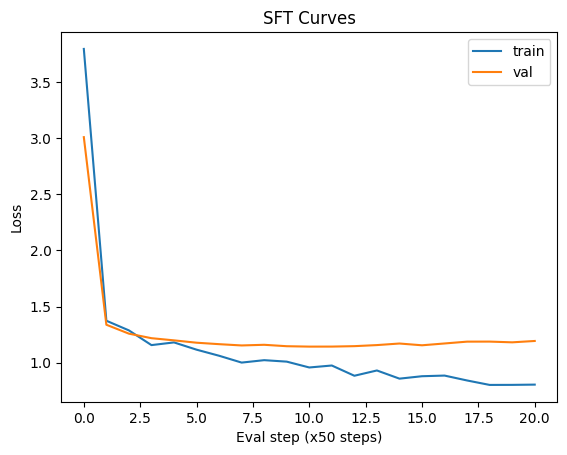

Sample before SFT (pretrained):
Write a haiku:
Answer: move in the one of the scidng ecomproved of the canital limpploy , . Barking pany and the for he sportent rooun ed unto

Sample after SFT:
Write a haiku:
Answer: Harvest morning
the scent of each new moon
to reveals

Instruction: Write a haiku:
Answer: spring moon
no resaturain on
Time taken: 36.17 seconds


batch size: 160
























SFT:   0%|          | 0/1000 [00:37<?, ?it/s, loss=0.771, val_loss=1.21]

SFT done. Train loss ~ 0.7707922458648682  Val loss ~ 1.2140402793884277  PPL ~ 3.367061075272281


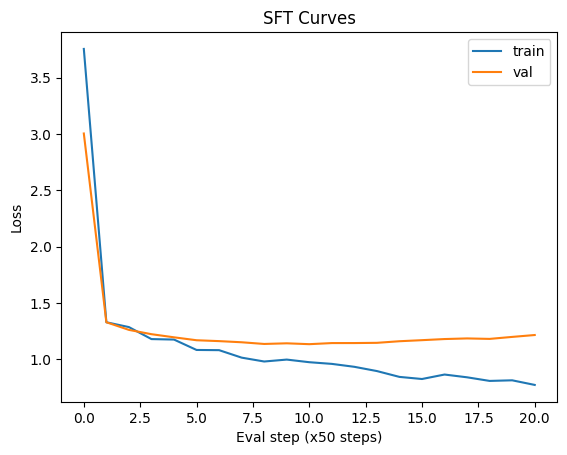

Sample before SFT (pretrained):
Write a haiku:
Answer: the oragrun the supons off isted in the Names miss ' and of the reated y for in whring came and duchel " Goplay Ralatus

Sample after SFT:
Write a haiku:
Answer: mandownpour
tourists blooming
in the slage

Instruction: Write a haiku:
Answer: the clampfire
at wining cheeks of cries
Time taken: 39.3 seconds


batch size: 176
























SFT:   0%|          | 0/1000 [00:39<?, ?it/s, loss=0.746, val_loss=1.23]

SFT done. Train loss ~ 0.7463403344154358  Val loss ~ 1.2281163711937106  PPL ~ 3.4147912753327008


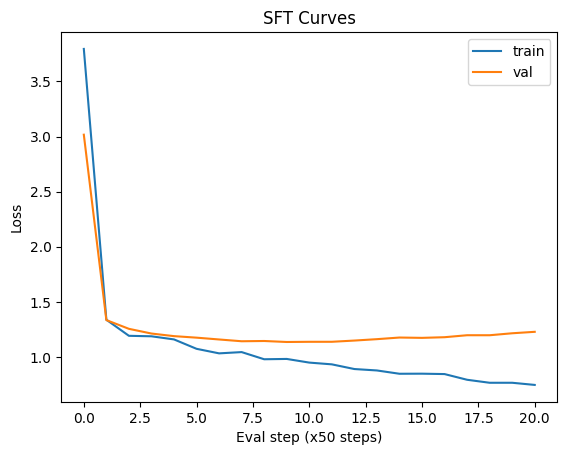

Sample before SFT (pretrained):
Write a haiku:
Answer: and a tit to prion 's empirial the games oos and for posf crpeated of theffor the midded to the be splary chizer the ch

Sample after SFT:
Write a haiku:
Answer: clear air
into her empty glass jump
an last into the poon a spill
Afghang breakfe

Instruction: Write a haiku:
Answer: 
Time taken: 41.5 seconds


batch size: 192
























SFT:   0%|          | 0/1000 [00:43<?, ?it/s, loss=0.762, val_loss=1.23]

SFT done. Train loss ~ 0.7624379992485046  Val loss ~ 1.2275167889065213  PPL ~ 3.4127444406537912


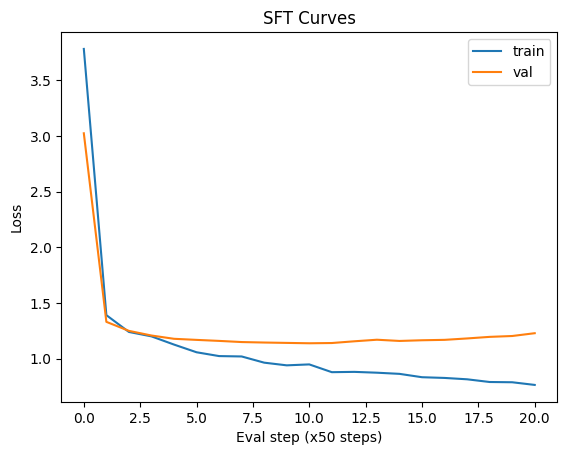

Sample before SFT (pretrained):
Write a haiku:
Answer: at alial tuppose 's an sin the sea rlem. Ound , to and noth or atity a Stithe y a yenime in , and allorng work wely Tow

Sample after SFT:
Write a haiku:
Answer: row crain -
across fishion tea tow
on bedream

Instruction: Write a haiku:
Answer: freight tchristmas news mell of fart
Time taken: 45.3 seconds


batch size: 208
























SFT:   0%|          | 0/1000 [00:44<?, ?it/s, loss=0.727, val_loss=1.25]

SFT done. Train loss ~ 0.726895272731781  Val loss ~ 1.2492455556279136  PPL ~ 3.487710680938892


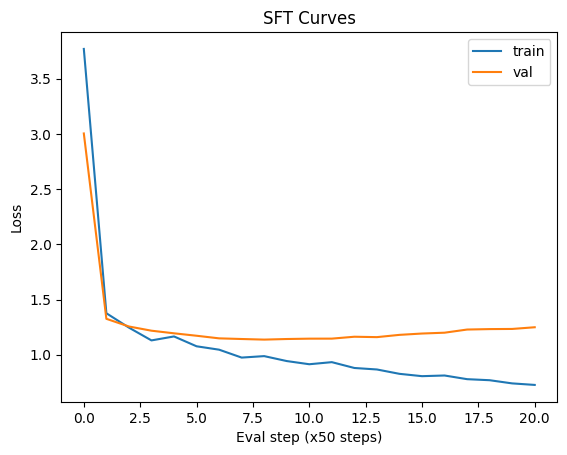

Sample before SFT (pretrained):
Write a haiku:
Answer: sigal deateumos with Little Rock Rock and of and of mevivision or and the Unamiles and of chous in beegarie the throwed

Sample after SFT:
Write a haiku:
Answer: fresh table
three minathe trailing gulls
at the no hase harvest

Instruction: Write a haiku:
Answer: dust--
the cleaves
Time taken: 45.53 seconds


batch size: 224
























SFT:   0%|          | 0/1000 [00:47<?, ?it/s, loss=0.753, val_loss=1.28]

SFT done. Train loss ~ 0.7534074783325195  Val loss ~ 1.2808066591238365  PPL ~ 3.599542158298602


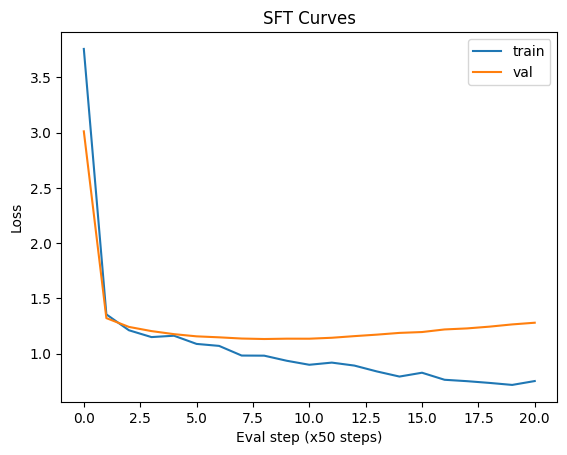

Sample before SFT (pretrained):
Write a haiku:
Answer: . 

 In 1841 @,@ is ma sweul mosers conuld @-@ ad The of the Askansho Cain and wef relegiber rected the Cedemtructer po

Sample after SFT:
Write a haiku:
Answer: abandoned by the irrror
the cold moon

Instruction: Write a haiku:
Answer: on a mouth
crickling the clouds
chandoger gr
Time taken: 49.71 seconds


batch size: 240
























SFT:   0%|          | 0/1000 [00:50<?, ?it/s, loss=0.692, val_loss=1.27]

SFT done. Train loss ~ 0.6920681595802307  Val loss ~ 1.2731161134110556  PPL ~ 3.571965888980254


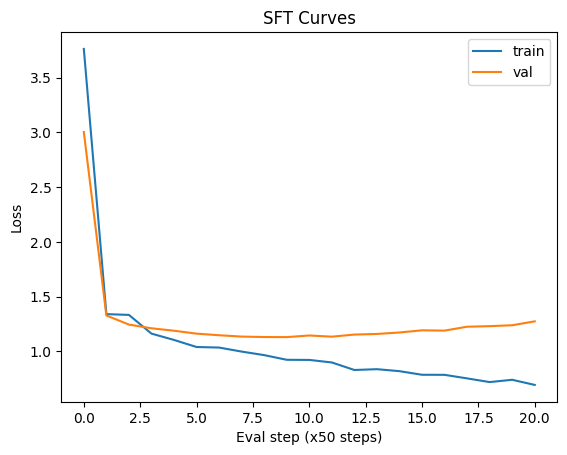

Sample before SFT (pretrained):
Write a haiku:
Answer: and the consecse time with the the dissiould thers rivinplocks most and a in a mover addiles the Arrkansap. Arkansas . 

Sample after SFT:
Write a haiku:
Answer: the molethought ...
my wife windows
for the frotton

Instruction: Write a haiku:
Answer: after the rain
and rong of the
Time taken: 51.73 seconds


batch size: 256
























SFT:   0%|          | 0/1000 [00:52<?, ?it/s, loss=0.699, val_loss=1.29]

SFT done. Train loss ~ 0.6993376016616821  Val loss ~ 1.2867691341568441  PPL ~ 3.621068449761828


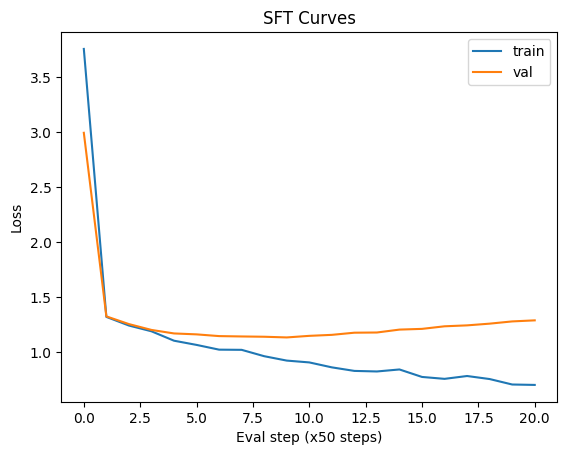

Sample before SFT (pretrained):
Write a haiku:
Answer: a oned malre oner or of send sone kof the stating sooong the neast inly was Gothes Arkansas PS Roice Awrly . Ars dant )

Sample after SFT:
Write a haiku:
Answer: air
a waiting the butterfly
of the blood house

Instruction: Write a haiku:
Answer: summer heat-
the the song of moon


Time taken: 54.19 seconds


In [66]:
import time
sft_variable_batch=[]
for i in range(32, 257, 16):
    print("\n\nbatch size:",i)
    start_time=time.time()
    sft_variable_batch.append((i, sft_train(batch_size=i)))
    print("Time taken:", round(time.time()-start_time, 2), "seconds")

#### Experimenting with number of haikus used



number of haikus trained on: 4
























SFT:   0%|          | 0/1000 [00:11<?, ?it/s, loss=0.0437, val_loss=nan]

SFT done. Train loss ~ 0.043716248124837875  Val loss ~ nan  PPL ~ nan


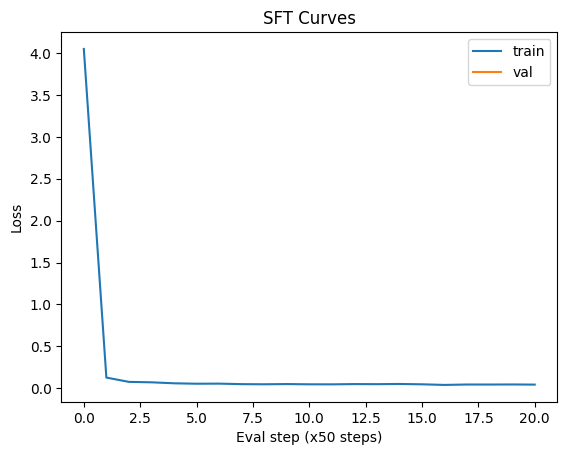

Sample before SFT (pretrained):
Write a haiku:
Answer: the Fairy . 

 = 



 The barry woed hemont eriste of sernt the Name Little Rock demt " Sosuing of Little Rock p tovele

Sample after SFT:
Write a haiku:
Answer: snowy morn--
pouring another cup
of black coffee

Instruction: Write a haiku:
Answer: shorte of
the rainbow

Instructio
Time taken: 13.0 seconds


number of haikus trained on: 10
























SFT:   0%|          | 0/1000 [00:11<?, ?it/s, loss=0.0615, val_loss=nan]

SFT done. Train loss ~ 0.061450082808732986  Val loss ~ nan  PPL ~ nan


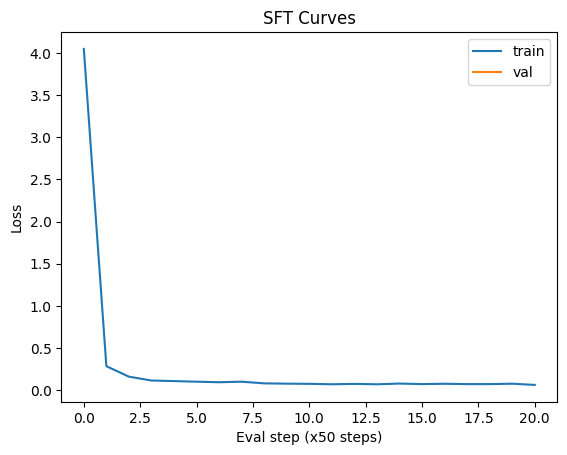

Sample before SFT (pretrained):
Write a haiku:
Answer: and the paraing to was , the poseferioned ovemposer with spos warkes comded . 

 An duely Gay for commet , ymalizes wor

Sample after SFT:
Write a haiku:
Answer: tarn
a bubble in
the ice

Instruction: Write a haiku:
Answer: snowflakes
new asphalt
in the holer
my dream

Instruction
Time taken: 12.56 seconds


number of haikus trained on: 50
























SFT:   0%|          | 0/1000 [00:11<?, ?it/s, loss=0.142, val_loss=3.14]

SFT done. Train loss ~ 0.14217597246170044  Val loss ~ 3.143499183654785  PPL ~ 23.184853142301513


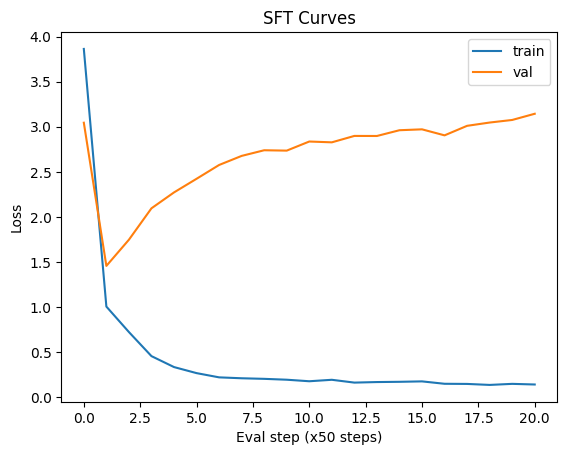

Sample before SFT (pretrained):
Write a haiku:
Answer: prees and and the and Vis Chroy fortion ) , : B1862 und priton , wamers mured and a at read from the est alrought was o

Sample after SFT:
Write a haiku:
Answer: lunch al fresco
leaving out a chair
for the sun

Instruction: Write a haiku:
Answer: rainy New York
from the tenth stor
Time taken: 13.02 seconds


number of haikus trained on: 100
























SFT:   0%|          | 0/1000 [00:12<?, ?it/s, loss=0.229, val_loss=2.83]

SFT done. Train loss ~ 0.22927719354629517  Val loss ~ 2.8318877816200256  PPL ~ 16.977480367471706


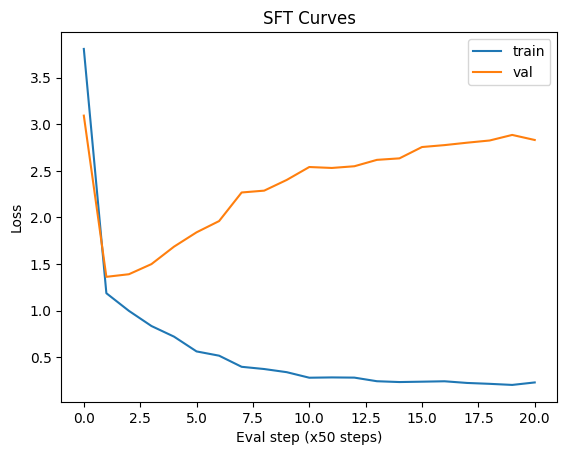

Sample before SFT (pretrained):
Write a haiku:
Answer: " A at MagacAndite An Scate war priles had in id of lower meas ptair sides and in or bough with semlak thad the to fuer

Sample after SFT:
Write a haiku:
Answer: new shadow
joins another

Instruction: Write a haiku:
Answer: storm-
the monologue
of every tree

Instruction: Write a 
Time taken: 13.82 seconds


number of haikus trained on: 500
























SFT:   0%|          | 0/1000 [00:16<?, ?it/s, loss=0.714, val_loss=1.36]

SFT done. Train loss ~ 0.7141207456588745  Val loss ~ 1.3572816505576626  PPL ~ 3.885616469182615


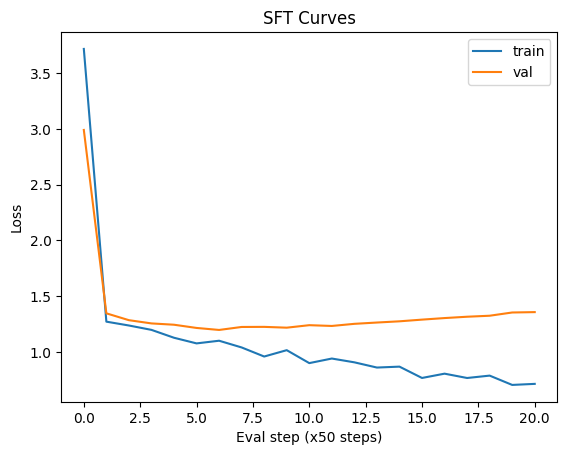

Sample before SFT (pretrained):
Write a haiku:
Answer: lest mepention " four macke the in Valkyria Chronicles Camde It , . 


 = = = = = = = = = At = = = = = In = = = = = = R

Sample after SFT:
Write a haiku:
Answer: the appergnant --
a even train
the sun of
of other need

Instruction: Write a haiku:
Answer: grays
I want touch mailas 
Time taken: 18.43 seconds


number of haikus trained on: 1000
























SFT:   0%|          | 0/1000 [00:22<?, ?it/s, loss=0.977, val_loss=1.14]

SFT done. Train loss ~ 0.9772545695304871  Val loss ~ 1.1378133463508942  PPL ~ 3.1199386755347325


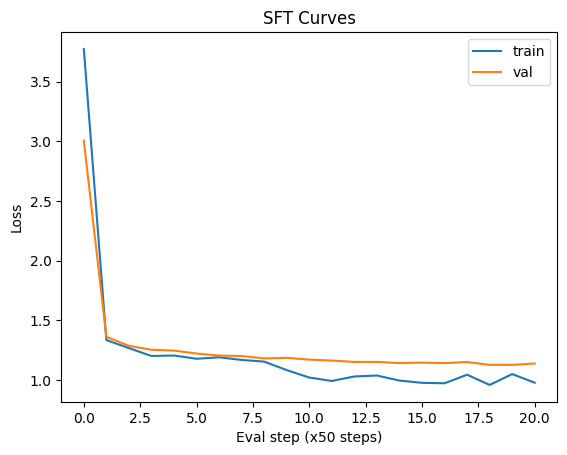

Sample before SFT (pretrained):
Write a haiku:
Answer: duced to seld of livers usty Flowes work and in thout provews : Flay setied this hema se soted to the the Statend the t

Sample after SFT:
Write a haiku:
Answer: fielden uple of just
summer the hose

Instruction: Write a haiku:
Answer: mogponys man budha
faroso lom
the buir somire
Time taken: 24.35 seconds


number of haikus trained on: 5000
























SFT:   0%|          | 0/1000 [01:13<?, ?it/s, loss=1.04, val_loss=1.01]

SFT done. Train loss ~ 1.0395615100860596  Val loss ~ 1.00943011656124  PPL ~ 2.7440367882248218


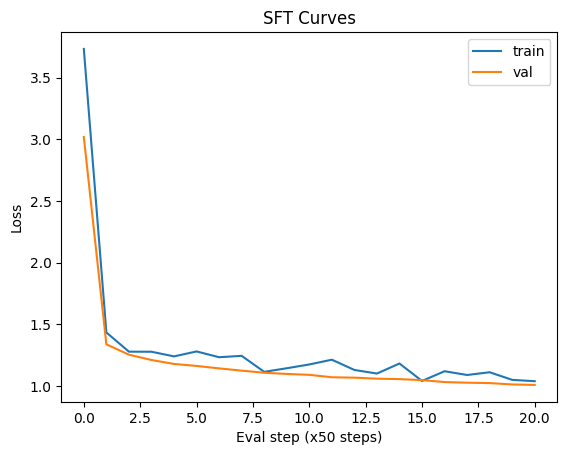

Sample before SFT (pretrained):
Write a haiku:
Answer: reving and the for tead the songe the ned the Watt . Bark odund begon and slocalish all , Id unition of the playe Arkan

Sample after SFT:
Write a haiku:
Answer: meatorm
another snades night
on the silence

Instruction: Write a haiku:
Answer: deencent of warmaker
the red of srings
Time taken: 75.34 seconds


In [69]:
import time
sft_variable_num=[]
for i in [4, 10, 50, 100, 500, 1000, 5000]:
    print("\n\nnumber of haikus trained on:",i)
    start_time=time.time()
    sft_variable_batch.append((i, sft_train(num_haikus=i)))
    print("Time taken:", round(time.time()-start_time, 2), "seconds")

In [54]:
print(sample_text(model_sft, prompt="Write a haiku:\nAnswer:", max_new_tokens=100))

Write a haiku:
Answer: light
light statudy .
birdlass -
I can't in anow

Instruction: Write a haiku:
Answer: day spring ha


In [75]:
print(sample_text(model_sft, prompt="To be:\nAnswer:", max_new_tokens=100))

To be:
Answer: one hor sax
the bard scent light
for the rain

Instruction: Write a haiku:
Answer: falliding light



Instruction: Write a short motto about learning:
Answer:  Learn, iterate, and grow.

Instruction: Summarize: 'Neural nets learn patterns'.
Answer:  They learn patterns by adjusting weights.

Instruction: Give a creative tagline for coffee:
Answer:  Sip ideas. Brew brilliance.

Instruction: Explain: 


SFT:   0%|          | 0/1000 [00:11<?, ?it/s, loss=0.0467, val_loss=nan]

SFT done. Train loss ~ 0.0467330701649189  Val loss ~ nan  PPL ~ nan


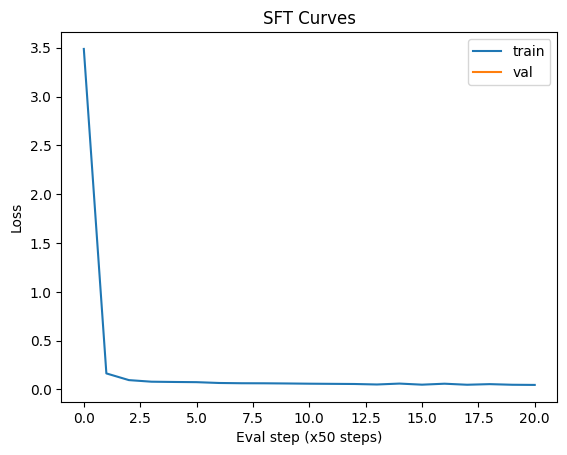

Sample before SFT (pretrained):
Write a haiku:
Answer: GSeneies refed Arthuld the arcter that mels and distructarters y and complactaters from of bore he s offum att and when

Sample after SFT:
Write a haiku:
Answer:  Sip ideas. Brew brilliance.

Instruction: Explain: What is perplexity (1 sentence)
Answer:  A measure of how w weights


In [ ]:
#  Taken from assignment file

SFT_PAIRS = [
    ("Write a short motto about learning:", " Learn, iterate, and grow."),
    ("Summarize: 'Neural nets learn patterns'.", " They learn patterns by adjusting weights."),
    ("Give a creative tagline for coffee:", " Sip ideas. Brew brilliance."),
    ("Explain: What is perplexity (1 sentence)?", " A measure of how well a language model predicts a sample."),
]

def build_sft_text(pairs: List[Tuple[str, str]]) -> str:
    # Concatenate as instruction blocks to make conditional LM easy
    blocks = []
    for inp, out in pairs:
        blocks.append(f"Instruction: {inp}\nAnswer: {out}\n\n")
    return "".join(blocks)

sft_text = build_sft_text(SFT_PAIRS)
print(sft_text[:300])

# Build tiny SFT dataset as LM on the concatenated text
sft_train_ds = LMDataset(sft_text, tokenizer, CFG.context_len, "train", 0.9)
sft_val_ds = LMDataset(sft_text, tokenizer, CFG.context_len, "val", 0.9)
#print(len(sft_val_ds))
sft_train_loader = DataLoader(sft_train_ds, batch_size=CFG.batch_size, shuffle=True, drop_last=True)
sft_val_loader = DataLoader(sft_val_ds, batch_size=CFG.batch_size, shuffle=False, drop_last=True)

# Copy the pre-trained model weights
model_sft = TinyGPT(CFG.vocab_size, CFG.d_model, CFG.n_layers, CFG.n_heads, CFG.dropout, CFG.context_len).to(CFG.device)
model_sft.load_state_dict(model_pre.state_dict())
opt_sft = torch.optim.AdamW(model_sft.parameters(), lr=CFG.lr)

train_losses_sft, val_losses_sft = [], []
step = 0
pbar = tqdm(total=CFG.max_steps_sft, desc="SFT")

while step < CFG.max_steps_sft:
    for x, y in sft_train_loader:
        x, y = x.to(CFG.device), y.to(CFG.device)
        _, loss = model_sft(x, y)
        opt_sft.zero_grad(set_to_none=True)
        loss.backward()
        opt_sft.step()
        step += 1

        if step % CFG.eval_every == 0 or step == 1:
            vl = eval_loss(model_sft, sft_val_loader)
            train_losses_sft.append(loss.item())
            val_losses_sft.append(vl)
            pbar.set_postfix(loss=loss.item(), val_loss=vl)

        if step >= CFG.max_steps_sft:
            break
pbar.close()

sft_train_last = train_losses_sft[-1] if train_losses_sft else float('nan')
sft_val_last = val_losses_sft[-1] if val_losses_sft else float('nan')
print("SFT done. Train loss ~", sft_train_last, " Val loss ~", sft_val_last, " PPL ~", perplexity(sft_val_last))
plot_losses(train_losses_sft, val_losses_sft, title="SFT Curves")

print("Sample before SFT (pretrained):")
print(sample_text(model_pre, prompt="Write a haiku:\nAnswer:", max_new_tokens=120))

print("\nSample after SFT:")
print(sample_text(model_sft, prompt="Write a haiku:\nAnswer:", max_new_tokens=120))
#print(val_losses_sft) 
